In [1]:
import numpy as np
import pandas as pd

# import dataset
df = pd.read_csv('./data/customer_churn_logistic_regression.csv', header=0)

# inspect data
df.info()
df.head()

<class 'pandas.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              1500 non-null   str    
 1   tenure_months            1500 non-null   int64  
 2   monthly_bill_rm          1500 non-null   float64
 3   support_tickets_last_6m  1500 non-null   int64  
 4   avg_monthly_data_gb      1500 non-null   float64
 5   late_payments_last_12m   1500 non-null   int64  
 6   contract_length_months   1500 non-null   int64  
 7   has_family_plan          1500 non-null   int64  
 8   uses_autopay             1500 non-null   int64  
 9   satisfaction_score       1500 non-null   int64  
 10  churned                  1500 non-null   int64  
dtypes: float64(2), int64(8), str(1)
memory usage: 137.8 KB


,customer_id,tenure_months,monthly_bill_rm,support_tickets_last_6m,avg_monthly_data_gb,late_payments_last_12m,contract_length_months,has_family_plan,uses_autopay,satisfaction_score,churned
0,C00001,7,118.61,6,115.6,0,24,1,1,1,1
1,C00002,44,199.26,3,73.0,6,1,1,0,1,1
2,C00003,58,73.06,0,43.5,2,6,0,1,7,0
3,C00004,34,174.06,0,324.0,5,36,1,0,10,0
4,C00005,41,48.45,8,185.3,7,36,1,1,9,1


In [2]:
# define X and y
X = df.drop(columns=['customer_id', 'churned'])
y = df['churned']

C:\Users\S13350\AppData\Local\Temp\ipykernel_20020\1308234438.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


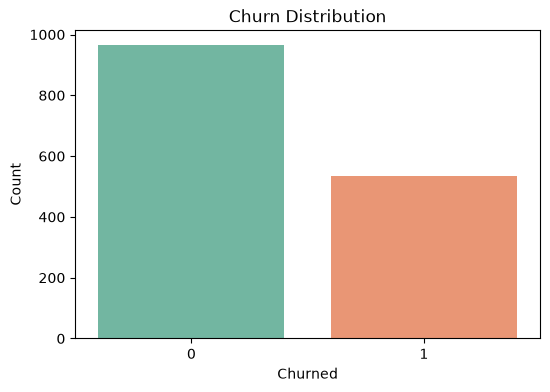

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='churned',
    palette='Set2'
)

plt.title('Churn Distribution')
plt.xlabel('Churned')
plt.ylabel('Count')
plt.show()

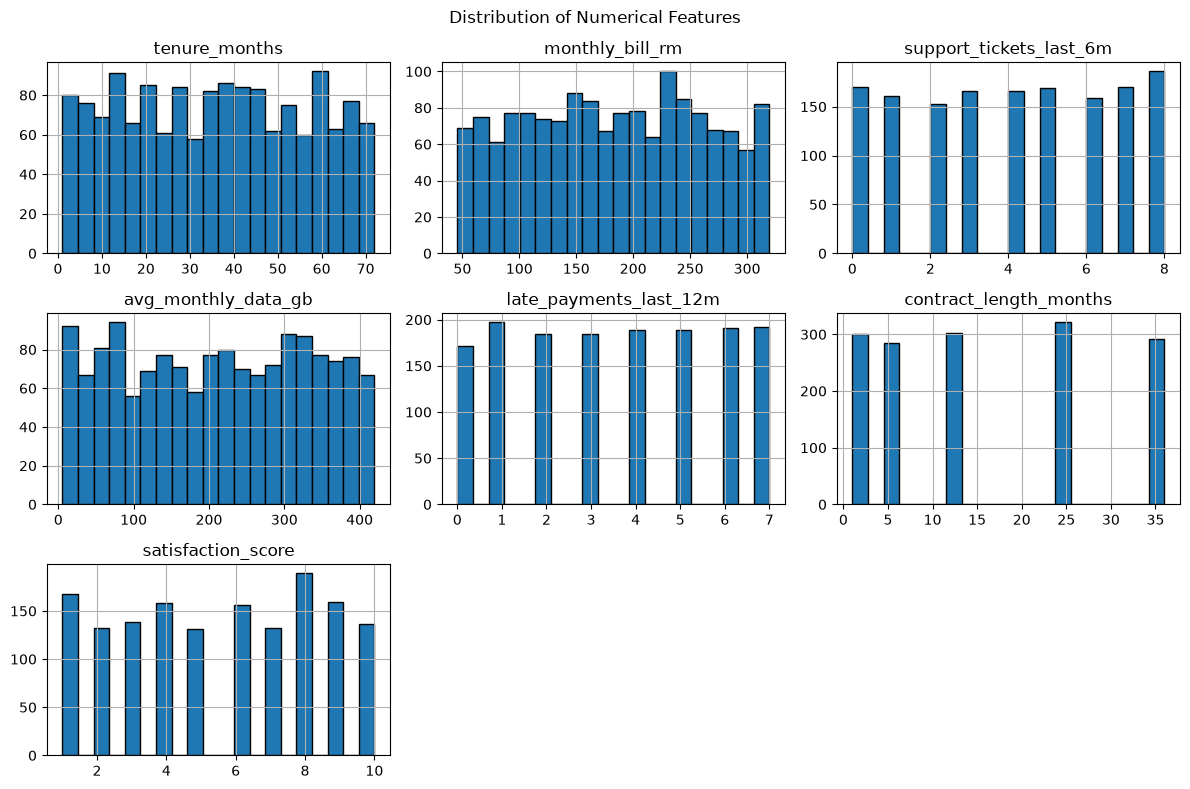

In [10]:
num_cols = [
    'tenure_months',
    'monthly_bill_rm',
    'support_tickets_last_6m',
    'avg_monthly_data_gb',
    'late_payments_last_12m',
    'contract_length_months',
    'satisfaction_score'
]

df[num_cols].hist(
    figsize=(12,8),
    bins=20,
    edgecolor='black'
)

plt.suptitle('Distribution of Numerical Features')
plt.tight_layout()
plt.show()

In [3]:
# split test data
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=7,
    stratify=y
)

In [4]:
# apply scaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [5]:
# train model
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [6]:
# make prediction
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [7]:
# evaluate model
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC AUC  :", roc_auc_score(y_test, y_prob))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy : 0.8106666666666666
Precision: 0.7837837837837838
Recall   : 0.6492537313432836
F1 Score : 0.710204081632653
ROC AUC  : 0.9050287979191182

Confusion Matrix
[[217  24]
 [ 47  87]]


In [8]:
# examine features effect
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
})

coef_df = coef_df.sort_values(
    'Coefficient',
    ascending=False
)

print(coef_df)

                   Feature  Coefficient
2  support_tickets_last_6m     0.784650
4   late_payments_last_12m     0.695325
1          monthly_bill_rm     0.658655
3      avg_monthly_data_gb     0.262433
6          has_family_plan    -0.207044
7             uses_autopay    -0.400058
5   contract_length_months    -0.438352
0            tenure_months    -0.453810
8       satisfaction_score    -1.029899


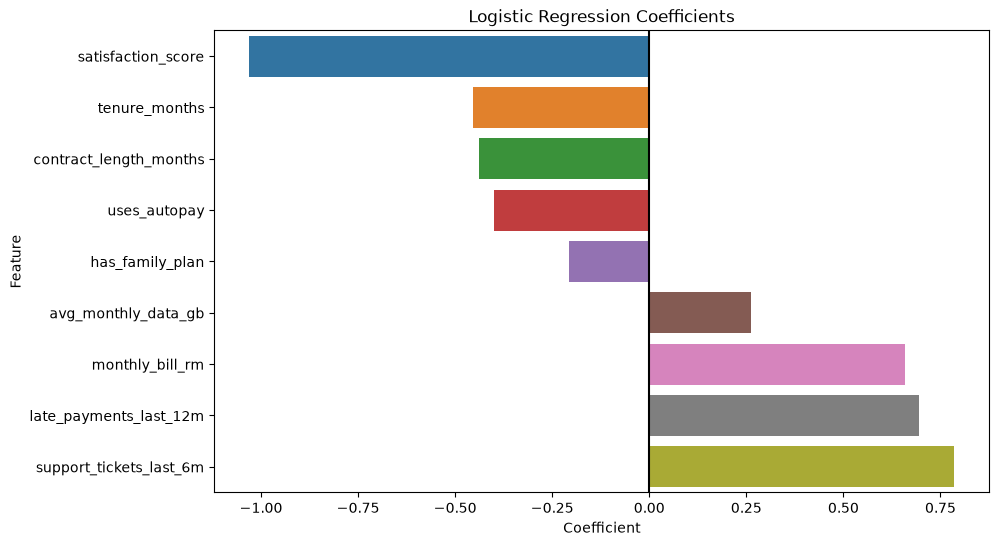

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient')

plt.figure(figsize=(10,6))

sns.barplot(
    data=coef_df,
    x='Coefficient',
    y='Feature',
    hue='Feature',
    dodge=False,
    legend=False
)

plt.axvline(0, color='black')
plt.title('Logistic Regression Coefficients')
plt.xlabel('Coefficient')
plt.ylabel('Feature')

plt.show()